In [75]:
from sklearn.datasets import fetch_california_housing

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

In [77]:
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [78]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

In [79]:
n = len(df)
print(n)

20640


In [80]:
n_train = int(0.6 * n)
n_val = int(0.2 * n)
n_test = int(0.2 * n)

np.random.seed(1)
idx = np.arange(n)
np.random.shuffle(idx)

shuffle_df = df.iloc[idx]
target_shuffled = housing.target[idx]

y_train = target_shuffled[:n_train]
y_val = target_shuffled[n_train:n_train+n_val]
y_test = target_shuffled[n_train+n_val:]

X_train = shuffle_df[:n_train]
X_val = shuffle_df[n_train:n_train+n_val]
X_test = shuffle_df[n_train+n_val:]

In [81]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [82]:
def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

In [83]:
y_pred = model.predict(X_train)
print('training rmse:', rmse(y_train, y_pred))
y_pred = model.predict(X_val)
print('validation rmse:', rmse(y_val, y_pred))
y_pred = model.predict(X_test)
print('test rmse:', rmse(y_test, y_pred))

training rmse: 0.7238452000065518
validation rmse: 0.7115836113261773
test rmse: 0.7448513431561158


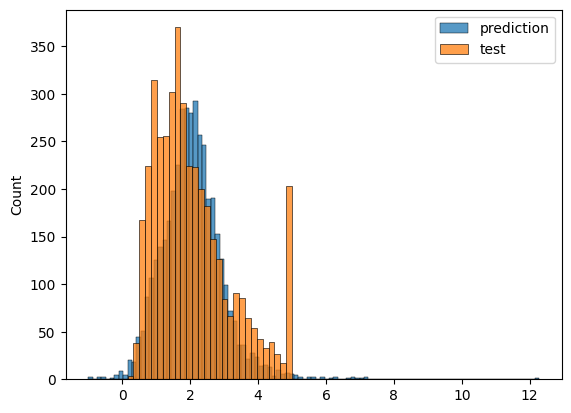

In [84]:
sns.histplot(y_pred, label = 'prediction')
sns.histplot(y_test, label = 'test')
plt.legend()
plt.show()

## Feature Scaling (StandardScaler)

Признаки в очень разных масштабах:
- Population: от ~3 до 35 000
- AveOccup: от ~0.5 до 1 000
- HouseAge: от 1 до 52

StandardScaler приводит каждый признак к: **mean = 0**, **std = 1**

**Важно:** скейлер обучаем (`fit`) только на train, а на val/test только применяем (`transform`). Иначе — data leakage!

In [85]:
X_train.describe()[['Population', 'AveOccup', 'HouseAge', 'MedInc']]

,Population,AveOccup,HouseAge,MedInc
count,12384.000000,12384.000000,12384.00000,12384.000000
mean,1421.923934,3.067331,28.75969,3.862366
std,1159.936613,11.408008,12.50725,1.908144
min,3.000000,0.692308,2.00000,0.499900
25%,784.000000,2.430968,18.00000,2.556800
50%,1167.000000,2.815576,29.00000,3.517900
75%,1718.000000,3.286007,37.00000,4.739375
max,35682.000000,1243.333333,52.00000,15.000100


In [86]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_scaled[:3]

array([[-0.32093542,  0.81878299, -0.41654494, -0.05557497, -0.26978765,
        -0.11309073, -0.72442254,  0.59070024],
       [-0.98736913,  0.65886928, -0.19413926, -0.14634412, -0.24047452,
        -0.04012628,  0.54717129, -0.11808733],
       [ 0.07905059,  1.37848097, -0.42704233, -0.21524959,  0.09662648,
         0.0623266 ,  0.99129413, -1.43583322]])

In [87]:
pd.DataFrame(X_train_scaled, columns=X_train.columns).describe()[['Population', 'AveOccup', 'HouseAge', 'MedInc']]

,Population,AveOccup,HouseAge,MedInc
count,1.238400e+04,1.238400e+04,1.238400e+04,1.238400e+04
mean,-4.618757e-17,-3.098297e-17,-1.029897e-16,-3.290506e-16
std,1.000040e+00,1.000040e+00,1.000040e+00,1.000040e+00
min,-1.223327e+00,-2.081976e-01,-2.139621e+00,-1.762237e+00
25%,-5.499867e-01,-5.578439e-02,-8.603110e-01,-6.842351e-01
50%,-2.197829e-01,-2.206919e-02,1.921444e-02,-1.805315e-01
75%,2.552622e-01,1.916940e-02,6.588693e-01,4.596321e-01
max,2.953735e+01,1.087233e+02,1.858222e+00,5.837182e+00


In [88]:
model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled, y_train)

print('=== LinearRegression ===')
print('train rmse:', rmse(y_train, model_scaled.predict(X_train_scaled)))
print('val   rmse:', rmse(y_val, model_scaled.predict(X_val_scaled)))
print('test  rmse:', rmse(y_test, model_scaled.predict(X_test_scaled)))

=== LinearRegression ===
train rmse: 0.7238452000065518
val   rmse: 0.7115836113261779
test  rmse: 0.7448513431561146


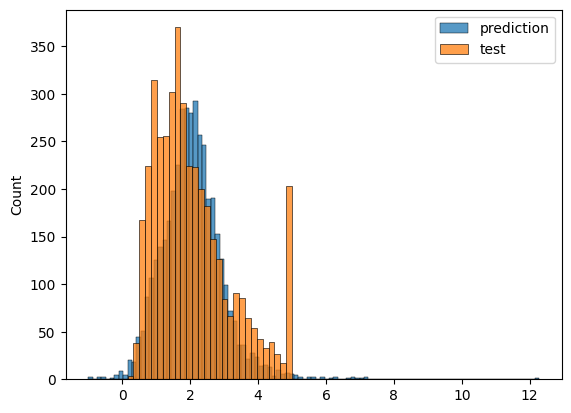

In [89]:
y_pred = model_scaled.predict(X_test_scaled)
sns.histplot(y_pred, label = 'prediction')
sns.histplot(y_test, label = 'test')
plt.legend()
plt.show()

In [90]:
alphas = [0.01, 0.1, 1, 10, 100]

print('=== Ridge + StandardScaler ===')
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    val_rmse = rmse(y_val, ridge.predict(X_val_scaled))
    print(f'alpha={alpha:<6}  val_rmse={val_rmse:.4f}')

=== Ridge + StandardScaler ===
alpha=0.01    val_rmse=0.7116
alpha=0.1     val_rmse=0.7116
alpha=1       val_rmse=0.7116
alpha=10      val_rmse=0.7116
alpha=100     val_rmse=0.7122


In [91]:
print('=== Коэффициенты ===')
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coef_raw': model.coef_,
    'coef_scaled': model_scaled.coef_
})
coef_df

=== Коэффициенты ===


,feature,coef_raw,coef_scaled
0,MedInc,4.502596e-01,0.859125
1,HouseAge,9.735043e-03,0.121754
2,AveRooms,-1.389067e-01,-0.303151
3,AveBedrms,8.667202e-01,0.333296
4,Population,5.439680e-07,0.000631
5,AveOccup,-4.371397e-03,-0.049867
6,Latitude,-4.175182e-01,-0.893091
7,Longitude,-4.323491e-01,-0.866177


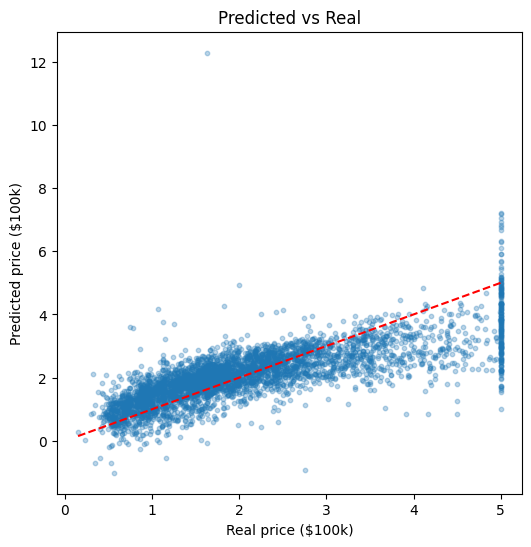

In [92]:
y_test_pred = model_scaled.predict(X_test_scaled)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Real price ($100k)')
plt.ylabel('Predicted price ($100k)')
plt.title('Predicted vs Real')
plt.show()